cesta nalezena


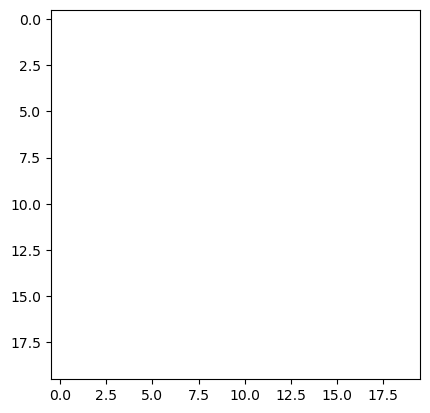

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

def nacti_data(nazev_souboru):
    soubor = np.genfromtxt(nazev_souboru, delimiter=",", dtype=int)
    matice = soubor.astype(bool)
    return matice

def obrazek_bludiste(zadana_matice):
    plt.imshow(zadana_matice, cmap='gray_r', origin='upper')

def zmena_policek(sablona, pocet_zmen):
    n = sablona.shape[0]
    for i in range(pocet_zmen):
        x, y = random.randint(0, n-1), random.randint(0, n-1)
        sablona[x,y] = not sablona[x,y]
    return sablona

def over_cestu(zadane_bludiste):
    navstiveno = set()
    k_prohledani = deque()
    k_prohledani.append((0,0))
    navstiveno.add((0,0))
    n = zadane_bludiste.shape[0]
    predchudce = {}
    
    
    while k_prohledani:
        x, y = k_prohledani.popleft()            
        if x==n-1 and y==n-1:
            
            obrazek_bludiste(zadane_bludiste)
            return True
            
        smery = [(0,1), (1,0), (0,-1), (-1,0)]
        random.shuffle(smery)
        for dx, dy in smery:
            nx, ny = x+dx, y+dy
            if 0<=nx<n and 0<=ny<n and not zadane_bludiste[nx,ny] and (nx, ny) not in navstiveno:
                k_prohledani.append((nx, ny))
                navstiveno.add((nx, ny))
                predchudce[(nx, ny)] = (x, y)

    
    return False
        
  
bludiste = nacti_data("sablony/had.csv")
while True:
    bludiste = nacti_data("sablony/prazdna.csv")
    zmena_policek(bludiste,0)
    if over_cestu(bludiste):
        print("cesta nalezena")
        break
            



